# 12. Support Vector Machine lề mềm từ đầu (Soft-Margin SVM from Scratch)

## 1. Cơ sở lý thuyết Chapter 27
Để xử lý dữ liệu không phân tách tuyến tính hoàn hảo, Soft-Margin SVM đưa vào biến bù trượt (slack variables) $\xi_i \ge 0$ và hàm mất mát bản lề (Hinge Loss) với hệ số đánh đổi $C$:
$$J(w, b) = \frac{1}{2} \|w\|^2 + C \sum_{i=1}^n \max(0, 1 - y_i (w^T x_i + b))$$
- Khi $C$ lớn: phạt nặng các điểm vi phạm lề -> Lề hẹp, ít chấp nhận lỗi (nguy cơ overfitting).
- Khi $C$ nhỏ: ưu tiên lề rộng, chấp nhận nhiều điểm vi phạm hơn -> Lề rộng, tổng quát hóa tốt hơn.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.models.svm_soft_margin import SoftMarginSVM
from src.metrics import calculate_metrics, confusion_matrix

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. Khảo sát ảnh hưởng của hệ số điều chuẩn C

In [2]:
c_values = [0.01, 0.1, 1.0, 10.0, 100.0]
c_results = []

for c in c_values:
    svm = SoftMarginSVM(C=c, epochs=2000, learning_rate=0.001, random_state=42)
    svm.fit(X_train_proc, y_train)

    y_pred = svm.predict(X_test_proc)
    y_score = svm.decision_function(X_test_proc)
    m = calculate_metrics(y_test, y_pred, y_score)

    c_results.append({
        'C': c,
        'Accuracy': m['Accuracy'],
        'Precision': m['Precision'],
        'Recall': m['Recall'],
        'F1_Score': m['F1_Score'],
        'ROC_AUC': m['ROC_AUC'],
        'Num_Support_Vectors': len(svm.support_vectors_)
    })

df_c = pd.DataFrame(c_results)
display(df_c)

,C,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Num_Support_Vectors
0,0.01,0.847458,0.821429,0.851852,0.836364,0.932870,173
1,0.10,0.813559,0.785714,0.814815,0.800000,0.929398,110
2,1.00,0.864407,0.880000,0.814815,0.846154,0.923611,91
3,10.00,0.864407,0.880000,0.814815,0.846154,0.921296,78
4,100.00,0.728814,0.648649,0.888889,0.750000,0.907407,60


## 3. Biểu đồ so sánh số lượng Support Vectors và độ chính xác

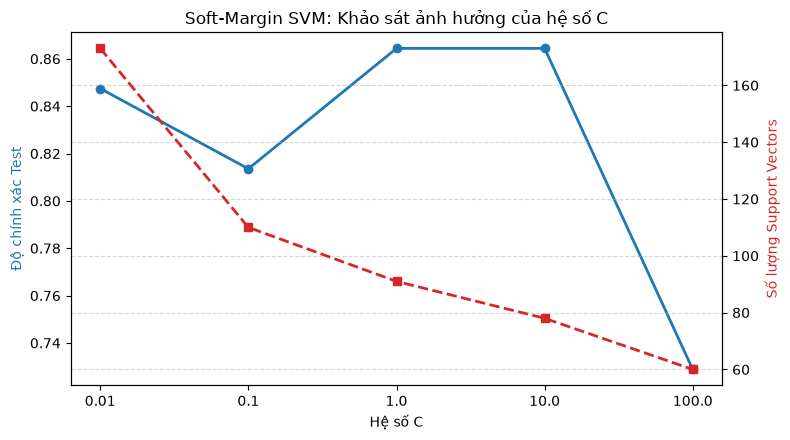

In [3]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax2 = ax1.twinx()

ax1.plot([str(c) for c in c_values], df_c['Accuracy'], color='tab:blue', marker='o', lw=2, label='Test Accuracy')
ax2.plot([str(c) for c in c_values], df_c['Num_Support_Vectors'], color='tab:red', marker='s', lw=2, linestyle='--', label='Số Support Vectors')

ax1.set_xlabel('Hệ số C')
ax1.set_ylabel('Độ chính xác Test', color='tab:blue')
ax2.set_ylabel('Số lượng Support Vectors', color='tab:red')
plt.title('Soft-Margin SVM: Khảo sát ảnh hưởng của hệ số C')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Phân tích kết quả
- Với $C=0.1$ đến $C=1.0$, mô hình đạt điểm cân bằng tốt nhất giữa độ rộng lề và tỷ lệ lỗi phân loại.
- Khi $C$ tăng cao, số lượng support vectors giảm do biên lề bị thu hẹp khắt khe, dẫn tới nguy cơ suy giảm độ chính xác tổng quát.